In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import voigt_profile
from scipy import integrate, interpolate
from lmfit import minimize, Parameters
import emcee
import corner
import pandas as pd

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Specify atomic parameters for LyA

In [3]:
wav0_rest = 1215.6701
f = 0.416400
gamma_nu = 6.265E8

Convert $\Gamma_\nu$ to $\Gamma_v$ (must be done in the rest frame)

In [4]:
# First convert wavelength to meters, then velocity to km/s
gamma_v = (gamma_nu*(wav0_rest*1e-10))*1e-3

Thomson scattering cross-section

In [5]:
sigma_0 = 2.654E-2 # In cm^-2

Specify the redshift, wavelength range of observation, and velocity pixel size

In [6]:
z_test = 0.1
wav0_obs_min = 1250
wav0_obs_max = 1450
delta_v_pix = 2.3

Use this information to generate the velocity array

In [7]:
wav0_obs = wav0_rest*(1+z_test) # Observed wavelength of transition
v_min = 3e+5*(wav0_obs_min-wav0_obs)/wav0_obs
v_max = 3e+5*(wav0_obs_max-wav0_obs)/wav0_obs
v = np.arange(v_min, v_max+delta_v_pix, delta_v_pix)

Generate the Ly$\alpha$ lines

In [8]:
N = 1e+12 # cm^-2
b = 12.9
sigma_v = b/np.sqrt(2)

In [9]:
def vp(v, N):
    
    tau = N*sigma_0*f*voigt_profile(v, sigma_v, gamma_v/(4*np.pi))*wav0_rest*1e-13
    flux = np.exp(-tau)
    
    return flux

Generate noise

In [10]:
err_std = 0.15
# Draw samples from a Gaussian of mean zero and above std dev
#np.random.seed(45)
noise = np.random.normal(loc=0, scale=err_std, size=len(v))
err = np.ones(len(v))*err_std

Text(0, 0.5, 'Continuum normalized flux')

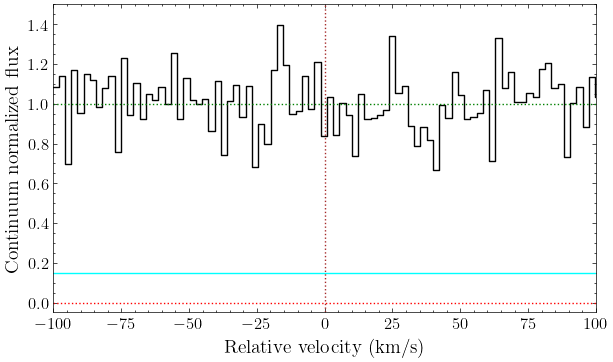

In [11]:
fig, ax = plt.subplots(1, figsize=(7,4))
ax.step(v, 1+noise, where='mid')
ax.step(v, err, color='cyan', where='mid')

ax.axhline(0, linestyle=':', color='red')
ax.axhline(1, linestyle=':', color='green')
ax.axvline(0, linestyle=':', color='brown')


ax.set_xlim(-100,100)
ax.set_ylim(-0.05,1.5)

ax.set_xlabel('Relative velocity (km/s)')
ax.set_ylabel('Continuum normalized flux')

Calculate upper limits on EW

In [12]:
b = 12.9
sigma_v = b/np.sqrt(2)
fwhm = 2*np.sqrt(2*np.log(2))*sigma_v

In [13]:
idx_fit = (v>-fwhm)&(v<fwhm)

In [14]:
EW_1sig = np.sqrt(np.sum(err[idx_fit][:-1]**2))*(delta_v_pix*wav0_rest/3e+5)*1e+3

In [15]:
logN_1sig_EW = np.log10((1*EW_1sig*1e-3/wav0_rest)*(3e+8/(wav0_rest*1e-10))*(2.654e-2*f)**-1)
logN_2sig_EW = np.log10((2*EW_1sig*1e-3/wav0_rest)*(3e+8/(wav0_rest*1e-10))*(2.654e-2*f)**-1)
logN_3sig_EW = np.log10((3*EW_1sig*1e-3/wav0_rest)*(3e+8/(wav0_rest*1e-10))*(2.654e-2*f)**-1)

Create a grid of logN

In [108]:
logN_grid = np.array([12, 12.47, 12.75, 13])

In [109]:
model_grid = np.zeros((len(logN_grid), len(v)))
noise_grid = np.zeros((len(logN_grid), len(v)))
flux_grid = np.zeros((len(logN_grid), len(v)))

In [110]:
chi_sq_grid = np.zeros(len(logN_grid))

In [111]:
idx_fit = (v>-110)&(v<110)

In [112]:
colors = ['red', 'green', 'blue', 'violet']

In [113]:
for i in range(len(logN_grid)):
    
    N = 10**logN_grid[i]
    model_grid[i,:] = vp(v, N)
    noise_grid[i,:] = np.random.normal(loc=0, scale=err_std, size=len(v))
    flux_grid[i,:] = model_grid[i,:]+noise_grid[i,:]
        
    chi_sq_grid[i] = np.sum((flux_grid[i,:][idx_fit]-model_grid[i,:][idx_fit])**2/err[idx_fit]**2)

In [114]:
delta_chi_sq_grid = chi_sq_grid-np.min(chi_sq_grid)

Text(0, 0.5, '$\\chi^2$')

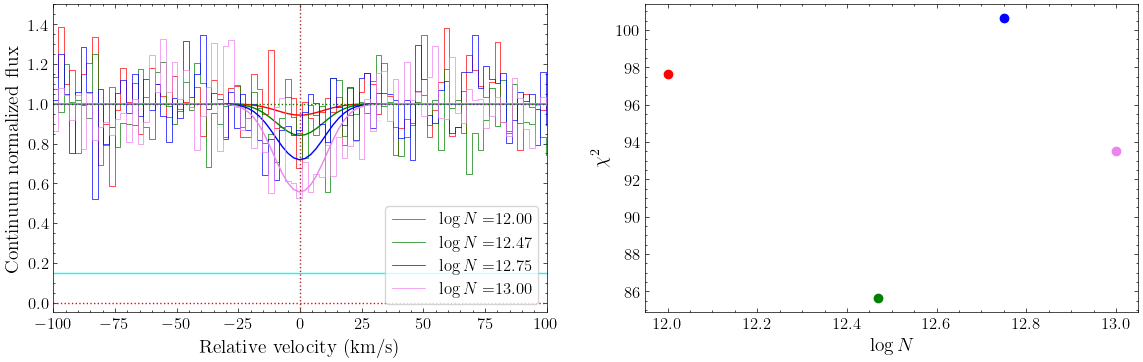

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

#axes[0].step(v, 1+noise, where='mid', label='Noise', lw=.5)
#axes[0].axvspan(xmin=-fwhm, xmax=fwhm, color='yellow', alpha=.1)

for i in range(len(logN_grid)):
    axes[0].step(v, flux_grid[i,:], where='mid', 
                 label=r'$\log N=$'+'{:.2f}'.format(logN_grid[i]), lw=.5, color=colors[i])
    axes[0].plot(v, model_grid[i,:], color=colors[i])
    axes[1].scatter(logN_grid[i], chi_sq_grid[i], color=colors[i])

axes[0].step(v, err, color='cyan', where='mid')

axes[0].axhline(0, linestyle=':', color='red')
axes[0].axhline(1, linestyle=':', color='green')
axes[0].axvline(0, linestyle=':', color='brown')

axes[0].set_xlim(-100,100)
axes[0].set_ylim(-0.05,1.5)

axes[0].legend(loc='lower right')

axes[0].set_xlabel('Relative velocity (km/s)')
axes[0].set_ylabel('Continuum normalized flux')


axes[1].set_xlabel(r'$\log N$')
axes[1].set_ylabel(r'$\chi^2$')

#axes[1].set_xlim(10, 12.6)
#axes[1].set_ylim(-0.2, 10)

In [197]:
logN_1sig, logN_1sig_EW

(12.025, 12.037227973114168)

In [198]:
logN_2sig, logN_2sig_EW

(12.325000000000001, 12.33825796877815)

In [199]:
logN_3sig, logN_3sig_EW

(12.505, 12.514349227833831)